### Creating all the figures

In [46]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════

RESULTS_DIR = "./results"

FIGURE_DIR = "./figures_final_pipeline"
os.makedirs(FIGURE_DIR, exist_ok=True)

CLASSIFIERS = ["svm", "gru", "patchtst", "inceptiontime"]

CLASSIFIER_LABELS = {
    "svm": "SVM",
    "gru": "GRU",
    "patchtst": "PatchTST",
    "inceptiontime": "InceptionTime",
}

sns.set_theme(style="whitegrid", context="paper")

print("Current working directory:", os.getcwd())
print("Results directory:", os.path.abspath(RESULTS_DIR))
print("Results directory exists:", os.path.exists(RESULTS_DIR))

txt_files = sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith(".txt")])
print("Number of txt files:", len(txt_files))
print("First 10 files:")
for f in txt_files[:10]:
    print(" ", f)


# ══════════════════════════════════════════════════════════════
# RESULT CATEGORIES
# ══════════════════════════════════════════════════════════════

result_categories = {
    "1_normalization": {
        "title": "Impact of Normalization",
        "short_label": "Normalization",
        "methods": [
            ("Raw", "nonorm"),
            ("Z-score", "zscore_all"),
            ("Min-max", "minmax_all"),
            ("Log", "log_all"),
            ("Hybrid", "hybrid"),
        ],
    },

    "2_timespan_reduction_removed": {
        "title": "Impact of Time-span Reduction",
        "short_label": "Time-span\nreduction",
        "methods": [
            ("6 h", "hybrid_6h"),
            ("9 h", "hybrid_9h"),
            ("12 h", "hybrid_12h"),
            ("18 h", "hybrid_18h"),
            ("Full", "hybrid"),
        ],
    },

    "3_borderline_cleaning": {
        "title": "Impact of Borderline Cleaning",
        "short_label": "Borderline\ncleaning",
        "methods": [
            ("Hybrid baseline", "hybrid"),
            ("ENN", "hybrid_enn"),
            ("Tomek Links", "hybrid_tomek"),
            ("NearMiss", "hybrid_nearmiss"),
        ],
    },

    "4_random_undersampling": {
        "title": "Impact of Random Undersampling",
        "short_label": "Random\nundersampling",
        "methods": [
            ("ENN baseline", "hybrid_enn"),
            ("RUS 8000", "enn_nonsep_8000"),
            ("RUS 4000", "enn_nonsep_4000"),
            ("RUS 2000", "enn_nonsep_2000"),
            ("RUS 1000", "enn_nonsep_1000"),
            ("RUS 500", "enn_nonsep_500"),
        ],
    },

    "5_oversampling_and_rus": {
        "title": "Impact of Oversampling and RUS",
        "short_label": "Oversampling\n+ RUS",
        "methods": [
            # SMOTE
            ("SMOTE balanced", "enn_smote_balanced"),
            ("SMOTE 8000", "enn_rus8000_smote8000"),
            ("SMOTE 4000", "enn_rus4000_smote4000"),
            ("SMOTE 2000", "enn_rus2000_smote2000"),
            ("SMOTE 1000", "enn_rus1000_smote1000"),
            ("SMOTE 500", "enn_rus500_smote500"),

            # ADASYN
            ("ADASYN balanced", "enn_adasyn_balanced"),
            ("ADASYN 8000", "enn_rus8000_adasyn8000"),
            ("ADASYN 4000", "enn_rus4000_adasyn4000"),
            ("ADASYN 2000", "enn_rus2000_adasyn2000"),
            ("ADASYN 1000", "enn_rus1000_adasyn1000"),
            ("ADASYN 500", "enn_rus500_adasyn500"),

            # TimeGAN
            ("TimeGAN balanced", "timegan_balanced"),
            ("TimeGAN 8000", "timegan_8000"),
            ("TimeGAN 4000", "timegan_4000"),
            ("TimeGAN 2000", "timegan_2000"),
            ("TimeGAN 1000", "timegan_1000"),
            ("TimeGAN 500", "timegan_500"),
        ],
    },
}

CATEGORY_ORDER = list(result_categories.keys())

Current working directory: /Users/samskanderi/SEP_DataAugmentation
Results directory: /Users/samskanderi/SEP_DataAugmentation/results
Results directory exists: True
Number of txt files: 140
First 10 files:
  gru_enn_adasyn_balanced.txt
  gru_enn_nonsep_1000.txt
  gru_enn_nonsep_2000.txt
  gru_enn_nonsep_4000.txt
  gru_enn_nonsep_500.txt
  gru_enn_nonsep_8000.txt
  gru_enn_rus1000_adasyn1000.txt
  gru_enn_rus1000_smote1000.txt
  gru_enn_rus2000_adasyn2000.txt
  gru_enn_rus2000_smote2000.txt


In [47]:
# ══════════════════════════════════════════════════════════════
# READ RESULT FILES
# Saved format:
# TP,TN,FP,FN,tss,hss1,hss2,gss,recall,f1,accuracy,train_time,infer_time
# ══════════════════════════════════════════════════════════════

def read_result_file_csv_style(filepath):
    rows = []

    with open(filepath, "r") as f:
        lines = f.readlines()

    for run_idx, line in enumerate(lines, start=1):
        line = line.strip()

        if not line:
            continue

        parts = line.split(",")

        if len(parts) < 13:
            print(f"Skipping malformed line in {filepath}: {line}")
            continue

        row = {
            "run": run_idx,
            "TP": int(float(parts[0])),
            "TN": int(float(parts[1])),
            "FP": int(float(parts[2])),
            "FN": int(float(parts[3])),
            "tss": float(parts[4]),
            "hss1": float(parts[5]),
            "hss2": float(parts[6]),
            "gss": float(parts[7]),
            "recall": float(parts[8]),
            "f1": float(parts[9]),
            "accuracy": float(parts[10]),
            "train_time": float(parts[11]),
            "infer_time": float(parts[12]),
        }

        rows.append(row)

    return rows


# ══════════════════════════════════════════════════════════════
# BUILD FULL RESULTS DATAFRAME
# One row = one run for one classifier/method/category
# ══════════════════════════════════════════════════════════════

rows = []
found_files = []
missing_files = []
empty_files = []

for category_key, category_info in result_categories.items():

    category_title = category_info["title"]
    category_short = category_info["short_label"]

    for classifier in CLASSIFIERS:

        for method_label, file_key in category_info["methods"]:

            filename = f"{classifier}_{file_key}.txt"
            filepath = os.path.join(RESULTS_DIR, filename)

            if not os.path.exists(filepath):
                missing_files.append(filename)
                continue

            found_files.append(filename)

            file_rows = read_result_file_csv_style(filepath)

            if len(file_rows) == 0:
                empty_files.append(filename)
                continue

            for r in file_rows:
                rows.append({
                    "category_key": category_key,
                    "category": category_title,
                    "category_short": category_short,
                    "classifier": classifier,
                    "classifier_label": CLASSIFIER_LABELS[classifier],
                    "method": method_label,
                    "file_key": file_key,
                    "filename": filename,
                    **r
                })

results_df = pd.DataFrame(rows)

print("Found matching files:", len(found_files))
print("Missing files:", len(missing_files))
print("Empty files:", len(empty_files))
print("Total run-level rows:", len(results_df))

print("\nDataframe preview:")
print(results_df.head())

results_df.to_csv(os.path.join(FIGURE_DIR, "all_pipeline_run_level_results.csv"), index=False)

Found matching files: 152
Missing files: 0
Empty files: 0
Total run-level rows: 304

Dataframe preview:
      category_key                 category category_short classifier  \
0  1_normalization  Impact of Normalization  Normalization        svm   
1  1_normalization  Impact of Normalization  Normalization        svm   
2  1_normalization  Impact of Normalization  Normalization        svm   
3  1_normalization  Impact of Normalization  Normalization        svm   
4  1_normalization  Impact of Normalization  Normalization        svm   

  classifier_label   method    file_key            filename  run  TP  ...  FN  \
0              SVM      Raw      nonorm      svm_nonorm.txt    1  15  ...  19   
1              SVM      Raw      nonorm      svm_nonorm.txt    2  15  ...  19   
2              SVM  Z-score  zscore_all  svm_zscore_all.txt    1  20  ...  14   
3              SVM  Z-score  zscore_all  svm_zscore_all.txt    2  20  ...  14   
4              SVM  Min-max  minmax_all  svm_minmax_

In [48]:
# ══════════════════════════════════════════════════════════════
# LONG FORMAT FOR TSS AND RECALL
# One row = one metric value
# ══════════════════════════════════════════════════════════════

plot_df = results_df.melt(
    id_vars=[
        "category_key",
        "category",
        "category_short",
        "classifier",
        "classifier_label",
        "method",
        "file_key",
        "filename",
        "run"
    ],
    value_vars=["tss", "recall"],
    var_name="metric",
    value_name="score"
)

plot_df["metric"] = plot_df["metric"].map({
    "tss": "TSS",
    "recall": "Recall"
})

plot_df["category_key"] = pd.Categorical(
    plot_df["category_key"],
    categories=CATEGORY_ORDER,
    ordered=True
)

print(plot_df.head())
print("Total plot rows:", len(plot_df))

plot_df.to_csv(os.path.join(FIGURE_DIR, "all_pipeline_tss_recall_long.csv"), index=False)

      category_key                 category category_short classifier  \
0  1_normalization  Impact of Normalization  Normalization        svm   
1  1_normalization  Impact of Normalization  Normalization        svm   
2  1_normalization  Impact of Normalization  Normalization        svm   
3  1_normalization  Impact of Normalization  Normalization        svm   
4  1_normalization  Impact of Normalization  Normalization        svm   

  classifier_label   method    file_key            filename  run metric  \
0              SVM      Raw      nonorm      svm_nonorm.txt    1    TSS   
1              SVM      Raw      nonorm      svm_nonorm.txt    2    TSS   
2              SVM  Z-score  zscore_all  svm_zscore_all.txt    1    TSS   
3              SVM  Z-score  zscore_all  svm_zscore_all.txt    2    TSS   
4              SVM  Min-max  minmax_all  svm_minmax_all.txt    1    TSS   

      score  
0  0.148127  
1  0.148127  
2  0.500292  
3  0.500292  
4  0.505307  
Total plot rows: 608


Classifier comparison figure rows: 528
Saved PDF: ./figures_final_pipeline/classifier_level_distribution_categories_sep_prediction.pdf
Saved PNG: ./figures_final_pipeline/classifier_level_distribution_categories_sep_prediction.png


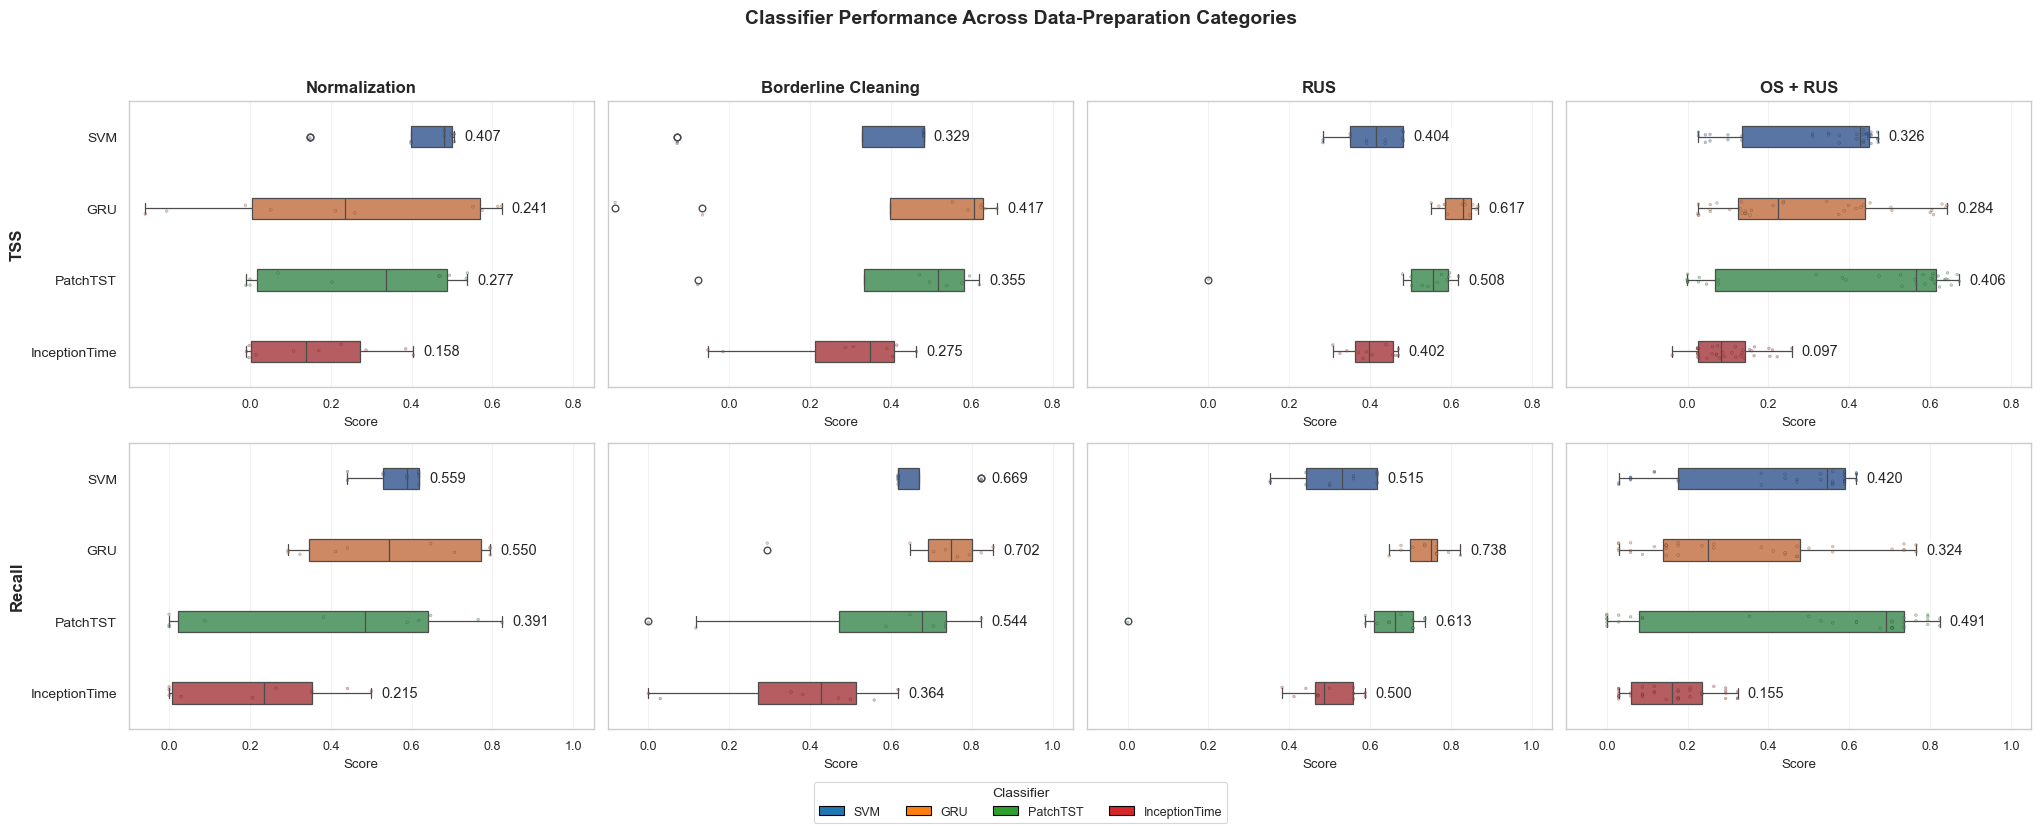

In [49]:
# ══════════════════════════════════════════════════════════════
# CLASSIFIER COMPARISON ACROSS MAIN DATA-PREPARATION CATEGORIES
# Uses existing plot_df only
# Categories:
#   Normalization
#   Borderline Cleaning
#   Random Undersampling
#   Oversampling + Random Undersampling
# Aggregation:
#   One box per classifier per category.
#   Each box contains all variants/runs within that category.
# Layout:
#   Rows    : TSS, Recall
#   Columns : Normalization, Borderline Cleaning, RUS, OS + RUS
#   Y-axis  : Classifier
#   Colors  : classifiers
#   Text    : mean score shown after each box/whisker
# Output:
#   PDF + PNG
# ══════════════════════════════════════════════════════════════

import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------
# Use the requested categories
# ---------------------------------------------------------

category_name_map = {
    "1_normalization": "Normalization",
    "3_borderline_cleaning": "Borderline Cleaning",
    "4_random_undersampling": "RUS",
    "5_oversampling_and_rus": "OS + RUS"
}

category_order = [
    "1_normalization",
    "3_borderline_cleaning",
    "4_random_undersampling",
    "5_oversampling_and_rus"
]

classifier_order = [
    "SVM",
    "GRU",
    "PatchTST",
    "InceptionTime"
]

figure_df = plot_df[
    plot_df["category_key"].isin(category_order)
].copy()

figure_df["category_label"] = figure_df["category_key"].map(category_name_map)

figure_df["classifier_label"] = pd.Categorical(
    figure_df["classifier_label"],
    categories=classifier_order,
    ordered=True
)

palette = sns.color_palette("tab10", n_colors=len(classifier_order))
classifier_colors = {
    clf: palette[i]
    for i, clf in enumerate(classifier_order)
}

print("Classifier comparison figure rows:", len(figure_df))

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(20.5, 8.2),
    sharey=True,
    sharex=False
)

for row_idx, metric in enumerate(["TSS", "Recall"]):

    for col_idx, category_key in enumerate(category_order):

        ax = axes[row_idx, col_idx]

        df_panel = figure_df[
            (figure_df["metric"] == metric) &
            (figure_df["category_key"] == category_key)
        ].copy()

        sns.boxplot(
            data=df_panel,
            y="classifier_label",
            x="score",
            hue="classifier_label",
            order=classifier_order,
            hue_order=classifier_order,
            orient="h",
            ax=ax,
            width=0.3,
            showfliers=True,
            linewidth=0.9,
            legend=False
        )

        sns.stripplot(
            data=df_panel,
            y="classifier_label",
            x="score",
            hue="classifier_label",
            order=classifier_order,
            hue_order=classifier_order,
            orient="h",
            ax=ax,
            dodge=False,
            size=2,
            alpha=0.40,
            linewidth=0.25,
            edgecolor="black",
            legend=False
        )

        # -------------------------------------------------
        # Add mean value after each box/whisker
        # -------------------------------------------------

        stats_values = (
            df_panel
            .groupby("classifier_label", observed=False)["score"]
            .agg(["mean", "max"])
            .reindex(classifier_order)
        )

        if metric == "TSS":
            ax.set_xlim(-0.3, 0.85)
            ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
            text_offset = 0.025
            max_text_x = 0.825
        else:
            ax.set_xlim(-0.1, 1.05)
            ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
            text_offset = 0.025
            max_text_x = 1.025

        for y_pos, clf in enumerate(classifier_order):
            mean_score = stats_values.loc[clf, "mean"]
            max_score = stats_values.loc[clf, "max"]

            if pd.notna(mean_score) and pd.notna(max_score):
                text_x = min(max_score + text_offset, max_text_x)

                ax.text(
                    text_x,
                    y_pos,
                    f"{mean_score:.3f}",
                    va="center",
                    ha="left",
                    fontsize=10.5,
                    bbox=dict(
                        facecolor="white",
                        edgecolor="none",
                        alpha=0.80,
                        pad=1.0
                    )
                )

        if row_idx == 0:
            ax.set_title(
                category_name_map[category_key],
                fontsize=12,
                fontweight="bold"
            )
        else:
            ax.set_title("")

        ax.set_xlabel("Score")
        ax.grid(True, axis="x", alpha=0.25)

        if col_idx == 0:
            ax.set_ylabel(metric, fontsize=12, fontweight="bold")
        else:
            ax.set_ylabel("")
            ax.tick_params(axis="y", labelleft=False)

        ax.tick_params(axis="y", labelsize=10)
        ax.tick_params(axis="x", labelsize=9)

legend_handles = [
    Patch(
        facecolor=classifier_colors[clf],
        edgecolor="black",
        label=clf
    )
    for clf in classifier_order
]

fig.legend(
    handles=legend_handles,
    title="Classifier",
    loc="lower center",
    ncol=4,
    fontsize=9,
    title_fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.015)
)

fig.suptitle(
    "Classifier Performance Across Data-Preparation Categories",
    fontsize=14,
    fontweight="bold",
    y=0.985
)

plt.tight_layout(rect=[0, 0.04, 1, 0.955])

pdf_path = os.path.join(FIGURE_DIR, "classifier_level_distribution_categories_sep_prediction.pdf")
png_path = os.path.join(FIGURE_DIR, "classifier_level_distribution_categories_sep_prediction.png")

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")

plt.show()

Overall classifier performance rows: 528
Overall classifier summary:
 index classifier_label metric     mean      std   median       min      max
     0              SVM Recall 0.488414 0.191507 0.558824  0.029412 0.823529
     1              SVM    TSS 0.352794 0.169177 0.434852 -0.128527 0.505307
     2              GRU Recall 0.479501 0.276483 0.485294  0.029412 0.852941
     3              GRU    TSS 0.354459 0.270642 0.422361 -0.282336 0.666834
     4         PatchTST Recall 0.504456 0.307793 0.647059  0.000000 0.823529
     5         PatchTST    TSS 0.398834 0.267727 0.529516 -0.377672 0.672324
     6    InceptionTime Recall 0.252228 0.189353 0.220588  0.000000 0.617647
     7    InceptionTime    TSS 0.183133 0.159022 0.138035 -0.052574 0.470221
Saved PDF: ./figures_final_pipeline/overall_classifier_performance_categories_sep_prediction.pdf
Saved PNG: ./figures_final_pipeline/overall_classifier_performance_categories_sep_prediction.png


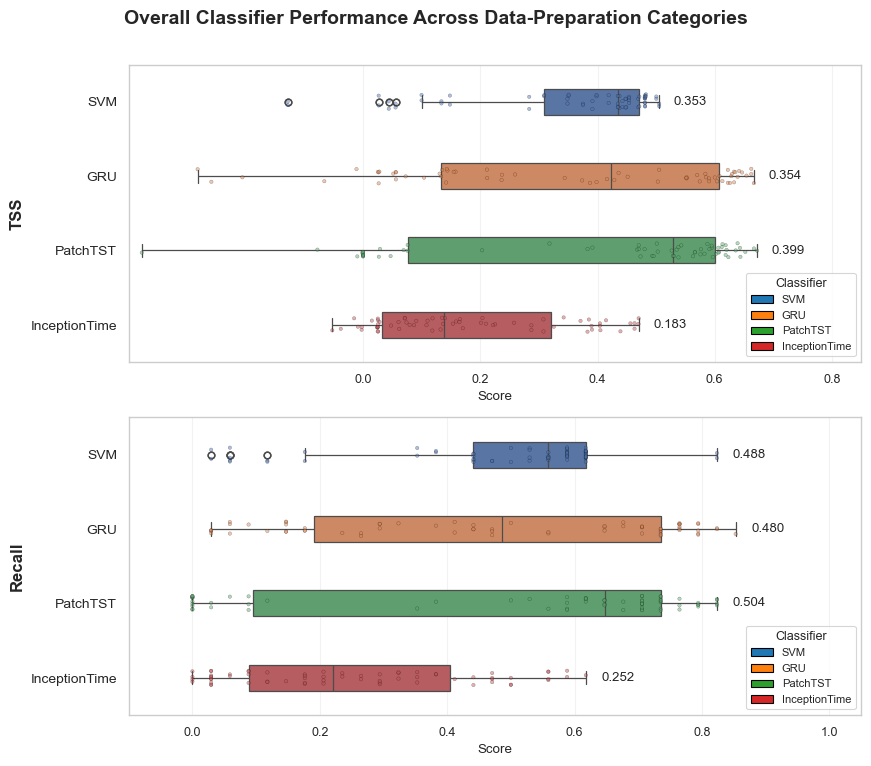

In [50]:
# ══════════════════════════════════════════════════════════════
# OVERALL CLASSIFIER PERFORMANCE ACROSS DATA-PREPARATION CATEGORIES
# Uses existing plot_df only
# Categories included:
#   Normalization
#   Borderline Cleaning
#   Random Undersampling
#   Oversampling + Random Undersampling
# Aggregation:
#   One box per classifier.
#   Each box contains all variants/runs across all included categories.
# Layout:
#   Top panel    : TSS
#   Bottom panel : Recall
#   Left label   : TSS / Recall
#   Y-axis       : Classifier
#   Colors       : classifiers
#   Text         : mean score shown after each box/whisker
# Output:
#   PDF + PNG
# ══════════════════════════════════════════════════════════════

import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------
# Categories included in the overall comparison
# ---------------------------------------------------------

category_order = [
    "1_normalization",
    "3_borderline_cleaning",
    "4_random_undersampling",
    "5_oversampling_and_rus"
]

classifier_order = [
    "SVM",
    "GRU",
    "PatchTST",
    "InceptionTime"
]

figure_df = plot_df[
    plot_df["category_key"].isin(category_order)
].copy()

figure_df["classifier_label"] = pd.Categorical(
    figure_df["classifier_label"],
    categories=classifier_order,
    ordered=True
)

palette = sns.color_palette("tab10", n_colors=len(classifier_order))
classifier_colors = {
    clf: palette[i]
    for i, clf in enumerate(classifier_order)
}

print("Overall classifier performance rows:", len(figure_df))

# ---------------------------------------------------------
# Optional summary table
# ---------------------------------------------------------

summary_table = (
    figure_df
    .groupby(["classifier_label", "metric"], as_index=False)["score"]
    .agg(["mean", "std", "median", "min", "max"])
    .reset_index()
)

print("Overall classifier summary:")
print(summary_table.to_string(index=False))

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8.8, 7.8),
    sharex=False
)

for ax, metric in zip(axes, ["TSS", "Recall"]):

    df_metric = figure_df[
        figure_df["metric"] == metric
    ].copy()

    sns.boxplot(
        data=df_metric,
        y="classifier_label",
        x="score",
        hue="classifier_label",
        order=classifier_order,
        hue_order=classifier_order,
        orient="h",
        ax=ax,
        width=0.35,
        showfliers=True,
        linewidth=0.9,
        legend=False
    )

    sns.stripplot(
        data=df_metric,
        y="classifier_label",
        x="score",
        hue="classifier_label",
        order=classifier_order,
        hue_order=classifier_order,
        orient="h",
        ax=ax,
        dodge=False,
        size=2.5,
        alpha=0.45,
        linewidth=0.25,
        edgecolor="black",
        legend=False
    )

    # -----------------------------------------------------
    # Add mean value after each box/whisker
    # -----------------------------------------------------

    stats_values = (
        df_metric
        .groupby("classifier_label", observed=False)["score"]
        .agg(["mean", "max"])
        .reindex(classifier_order)
    )

    if metric == "TSS":
        ax.set_xlim(-0.4, 0.85)
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
        text_offset = 0.025
        max_text_x = 0.825
    else:
        ax.set_xlim(-0.1, 1.05)
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        text_offset = 0.025
        max_text_x = 1.025

    for y_pos, clf in enumerate(classifier_order):
        mean_score = stats_values.loc[clf, "mean"]
        max_score = stats_values.loc[clf, "max"]

        if pd.notna(mean_score) and pd.notna(max_score):
            text_x = min(max_score + text_offset, max_text_x)

            ax.text(
                text_x,
                y_pos,
                f"{mean_score:.3f}",
                va="center",
                ha="left",
                fontsize= 9.5,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.80,
                    pad=1.0
                )
            )

    ax.set_xlabel("Score")
    ax.set_ylabel(metric, fontsize=12, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.25)

    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=9)

    legend_handles = [
        Patch(
            facecolor=classifier_colors[clf],
            edgecolor="black",
            label=clf
        )
        for clf in classifier_order
    ]

    ax.legend(
        handles=legend_handles,
        title="Classifier",
        loc="lower right",
        fontsize=8,
        title_fontsize=9,
        frameon=True
    )

fig.suptitle(
    "Overall Classifier Performance Across Data-Preparation Categories",
    fontsize=14,
    fontweight="bold",
    y=0.975
)

plt.tight_layout(rect=[0, 0, 1, 0.965])

pdf_path = os.path.join(FIGURE_DIR, "overall_classifier_performance_categories_sep_prediction.pdf")
png_path = os.path.join(FIGURE_DIR, "overall_classifier_performance_categories_sep_prediction.png")

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")

plt.show()

Run-level rows before averaging: 264
Average plot rows: 132
Overall TSS–Recall summary by classifier:
classifier_label  mean_tss  std_tss  mean_recall  std_recall
             SVM  0.352794 0.170493     0.488414    0.192997
             GRU  0.354459 0.263357     0.479501    0.259860
        PatchTST  0.398834 0.254450     0.504456    0.290033
   InceptionTime  0.183133 0.154195     0.252228    0.181124
Saved PDF: ./figures_final_pipeline/tss_recall_tradeoff_categories_sep_prediction.pdf
Saved PNG: ./figures_final_pipeline/tss_recall_tradeoff_categories_sep_prediction.png


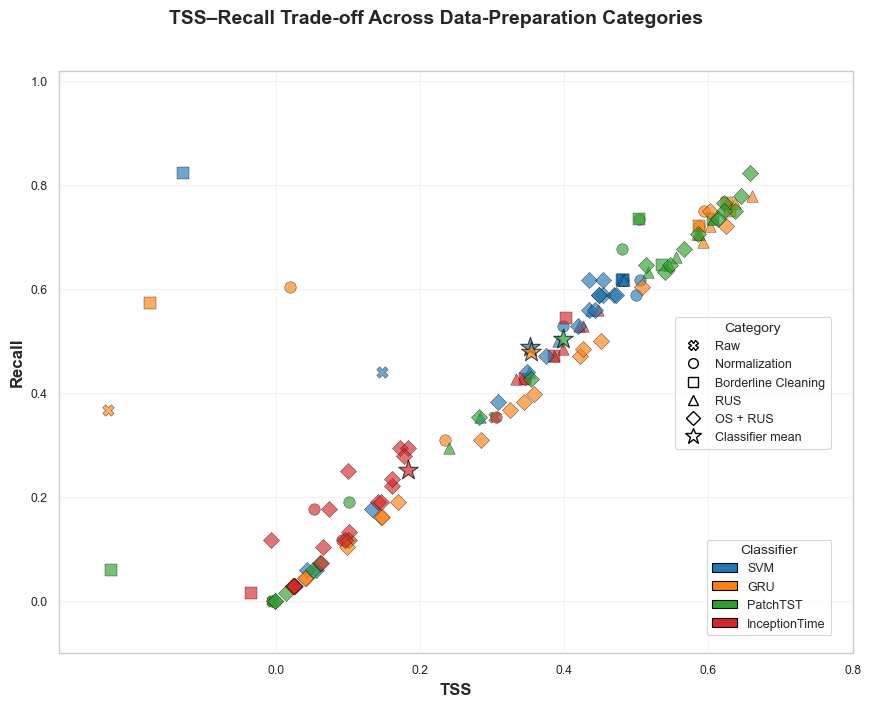

In [51]:
# ══════════════════════════════════════════════════════════════
# TSS–RECALL TRADE-OFF — FINAL FAST + SAFE VERSION
# Uses existing plot_df only
# Shows average of the 2 runs only
# Categories included:
#   Raw
#   Normalization
#   Borderline Cleaning
#   Random Undersampling
#   Oversampling + Random Undersampling
# Layout:
#   One scatter plot
#   X-axis : TSS
#   Y-axis : Recall
#   Colors : classifiers
#   Markers: data-preparation categories + Raw
# Output:
#   PDF + PNG
# ══════════════════════════════════════════════════════════════

import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------
# Categories included
# ---------------------------------------------------------

category_name_map = {
    "1_normalization": "Normalization",
    "3_borderline_cleaning": "Borderline Cleaning",
    "4_random_undersampling": "RUS",
    "5_oversampling_and_rus": "OS + RUS"
}

category_order = [
    "1_normalization",
    "3_borderline_cleaning",
    "4_random_undersampling",
    "5_oversampling_and_rus"
]

classifier_order = [
    "SVM",
    "GRU",
    "PatchTST",
    "InceptionTime"
]

marker_group_order = [
    "Raw",
    "Normalization",
    "Borderline Cleaning",
    "RUS",
    "OS + RUS"
]

# ---------------------------------------------------------
# Keep only needed rows and columns
# ---------------------------------------------------------

needed_cols = [
    "category_key",
    "classifier",
    "classifier_label",
    "method",
    "file_key",
    "filename",
    "run",
    "metric",
    "score"
]

tradeoff_df = plot_df.loc[
    plot_df["category_key"].isin(category_order),
    needed_cols
].copy()

tradeoff_df["category_label"] = tradeoff_df["category_key"].map(category_name_map)

# ---------------------------------------------------------
# Give Raw its own marker group
# ---------------------------------------------------------

tradeoff_df["marker_group"] = tradeoff_df["category_label"]

tradeoff_df.loc[
    (tradeoff_df["category_key"] == "1_normalization") &
    (tradeoff_df["method"] == "Raw"),
    "marker_group"
] = "Raw"

# ---------------------------------------------------------
# Convert grouping columns to string to prevent categorical expansion
# ---------------------------------------------------------

string_cols = [
    "category_key",
    "category_label",
    "marker_group",
    "classifier",
    "classifier_label",
    "method",
    "file_key",
    "filename",
    "metric"
]

for col in string_cols:
    tradeoff_df[col] = tradeoff_df[col].astype(str)

# ---------------------------------------------------------
# Fast TSS / Recall pairing without pivot_table
# One row = one run
# ---------------------------------------------------------

id_cols = [
    "category_key",
    "category_label",
    "marker_group",
    "classifier",
    "classifier_label",
    "method",
    "file_key",
    "filename",
    "run"
]

tss_df = (
    tradeoff_df[tradeoff_df["metric"] == "TSS"]
    [id_cols + ["score"]]
    .rename(columns={"score": "TSS"})
)

recall_df = (
    tradeoff_df[tradeoff_df["metric"] == "Recall"]
    [id_cols + ["score"]]
    .rename(columns={"score": "Recall"})
)

tradeoff_wide = pd.merge(
    tss_df,
    recall_df,
    on=id_cols,
    how="inner"
)

# ---------------------------------------------------------
# Average the 2 runs
# One row = one classifier/method/category average
# ---------------------------------------------------------

avg_cols = [
    "category_key",
    "category_label",
    "marker_group",
    "classifier",
    "classifier_label",
    "method",
    "file_key",
    "filename"
]

for col in avg_cols:
    tradeoff_wide[col] = tradeoff_wide[col].astype(str)

tradeoff_avg = (
    tradeoff_wide
    .groupby(avg_cols, as_index=False, sort=False, observed=True)
    .agg(
        TSS=("TSS", "mean"),
        Recall=("Recall", "mean"),
        n_runs=("run", "nunique")
    )
)

# Keep valid classifier and marker groups only
tradeoff_avg = tradeoff_avg[
    tradeoff_avg["classifier_label"].isin(classifier_order) &
    tradeoff_avg["marker_group"].isin(marker_group_order)
].copy()

print("Run-level rows before averaging:", len(tradeoff_wide))
print("Average plot rows:", len(tradeoff_avg))

# ---------------------------------------------------------
# Optional summary table
# ---------------------------------------------------------

summary_table = (
    tradeoff_avg
    .groupby("classifier_label", as_index=False, sort=False, observed=True)
    .agg(
        mean_tss=("TSS", "mean"),
        std_tss=("TSS", "std"),
        mean_recall=("Recall", "mean"),
        std_recall=("Recall", "std")
    )
)

print("Overall TSS–Recall summary by classifier:")
print(summary_table.to_string(index=False))

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

palette = sns.color_palette("tab10", n_colors=len(classifier_order))
classifier_colors = {
    clf: palette[i]
    for i, clf in enumerate(classifier_order)
}

category_markers = {
    "Raw": "X",
    "Normalization": "o",
    "Borderline Cleaning": "s",
    "RUS": "^",
    "OS + RUS": "D"
}

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8.8, 7.2)
)

for marker_group in marker_group_order:
    for clf in classifier_order:

        df_plot = tradeoff_avg[
            (tradeoff_avg["marker_group"] == marker_group) &
            (tradeoff_avg["classifier_label"] == clf)
        ]

        if df_plot.empty:
            continue

        ax.scatter(
            df_plot["TSS"],
            df_plot["Recall"],
            s=68,
            alpha=0.65,
            marker=category_markers[marker_group],
            color=classifier_colors[clf],
            edgecolor="black",
            linewidth=0.35
        )

# ---------------------------------------------------------
# Add classifier mean points
# Mean over averaged method/category points
# ---------------------------------------------------------

mean_points = (
    tradeoff_avg
    .groupby("classifier_label", as_index=False, sort=False, observed=True)
    .agg(
        mean_tss=("TSS", "mean"),
        mean_recall=("Recall", "mean")
    )
)

for _, row in mean_points.iterrows():
    clf = row["classifier_label"]

    ax.scatter(
        row["mean_tss"],
        row["mean_recall"],
        s=220,
        marker="*",
        alpha=0.70,
        color=classifier_colors[clf],
        edgecolor="black",
        linewidth=0.8,
        zorder=5
    )

# ---------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------

ax.set_xlabel("TSS", fontsize=12, fontweight="bold")
ax.set_ylabel("Recall", fontsize=12, fontweight="bold")

ax.set_xlim(-0.3, 0.8)
ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])

ax.set_ylim(-0.1, 1.02)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

ax.grid(True, alpha=0.25)

# ---------------------------------------------------------
# Legends
# ---------------------------------------------------------

classifier_handles = [
    Patch(
        facecolor=classifier_colors[clf],
        edgecolor="black",
        label=clf
    )
    for clf in classifier_order
]

category_handles = [
    Line2D(
        [0],
        [0],
        marker=category_markers[cat],
        color="black",
        linestyle="",
        markersize=7,
        markerfacecolor="white",
        markeredgecolor="black",
        label=cat
    )
    for cat in marker_group_order
]

mean_handle = [
    Line2D(
        [0],
        [0],
        marker="*",
        color="black",
        linestyle="",
        markersize=12,
        markerfacecolor="white",
        markeredgecolor="black",
        label="Classifier mean"
    )
]

legend_1 = ax.legend(
    handles=classifier_handles,
    title="Classifier",
    loc="lower right",
    bbox_to_anchor=(0.98, 0.02),
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

ax.add_artist(legend_1)

legend_2 = ax.legend(
    handles=category_handles + mean_handle,
    title="Category",
    loc="lower right",
    bbox_to_anchor=(0.98, 0.34),
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

fig.suptitle(
    "TSS–Recall Trade-off Across Data-Preparation Categories",
    fontsize=14,
    fontweight="bold",
    y=0.975
)

plt.tight_layout(rect=[0, 0, 1, 0.955])

pdf_path = os.path.join(FIGURE_DIR, "tss_recall_tradeoff_categories_sep_prediction.pdf")
png_path = os.path.join(FIGURE_DIR, "tss_recall_tradeoff_categories_sep_prediction.png")

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")

plt.show()

Selected final best configuration per classifier based on mean TSS:
classifier_label           category_key category_label          method method_clean  mean_tss
             GRU 4_random_undersampling            RUS        RUS 2000         2000  0.660547
   InceptionTime 4_random_undersampling            RUS        RUS 8000         8000  0.447618
        PatchTST 5_oversampling_and_rus             OS ADASYN balanced  ADASYN only  0.657714
             SVM        1_normalization           Norm         Min-max      Min-Max  0.505307
Saved PDF: ./figures_final_pipeline/final_best_configuration_per_classifier_sep_prediction.pdf
Saved PNG: ./figures_final_pipeline/final_best_configuration_per_classifier_sep_prediction.png


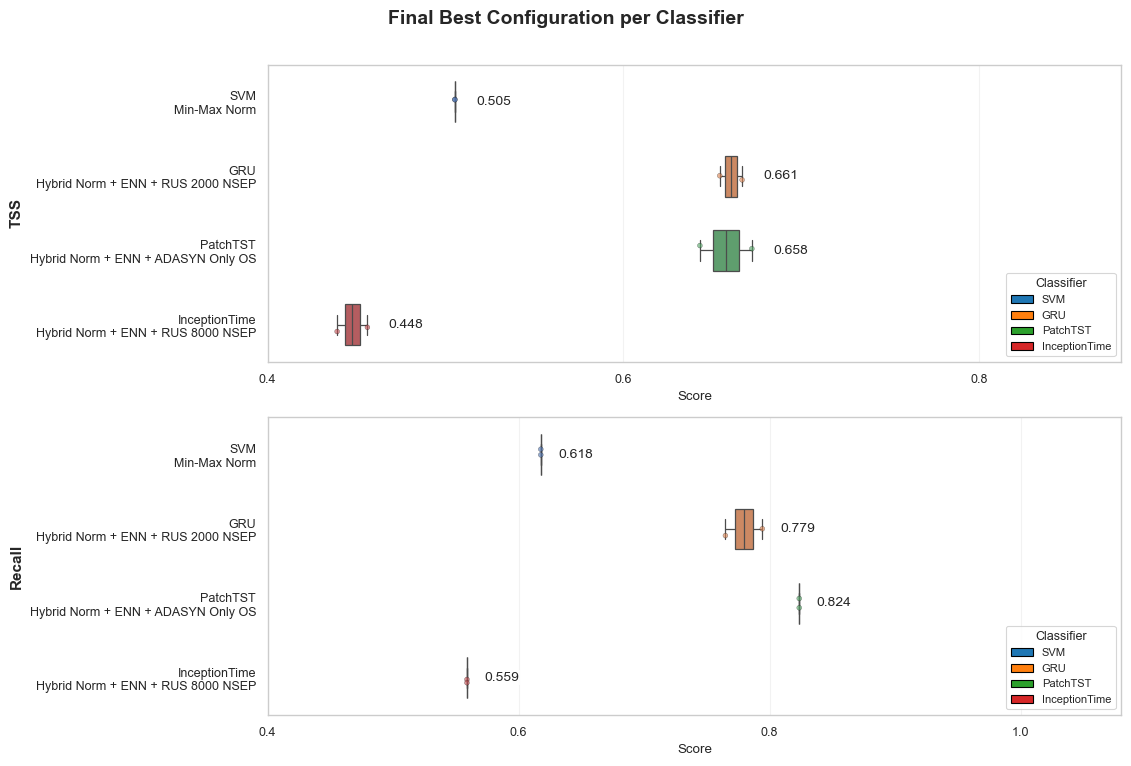

In [52]:
# ══════════════════════════════════════════════════════════════
# FINAL BEST CONFIGURATION PER CLASSIFIER
# Uses existing plot_df only
# Categories included:
#   Normalization
#   Borderline Cleaning
#   Random Undersampling
#   Oversampling + Random Undersampling
# Selection:
#   For each classifier, select the single method/category with
#   the highest mean TSS.
# Layout:
#   Top panel    : TSS
#   Bottom panel : Recall
#   Left label   : TSS / Recall
#   Y-axis       : Classifier + concise selected configuration
#   Colors       : classifiers
#   Text         : mean score shown after each box/whisker
# Output:
#   PDF + PNG
# ══════════════════════════════════════════════════════════════

import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------
# Categories included
# ---------------------------------------------------------

category_name_map = {
    "1_normalization": "Norm",
    "3_borderline_cleaning": "Clean",
    "4_random_undersampling": "RUS",
    "5_oversampling_and_rus": "OS"
}

category_order = [
    "1_normalization",
    "3_borderline_cleaning",
    "4_random_undersampling",
    "5_oversampling_and_rus"
]

classifier_order = [
    "SVM",
    "GRU",
    "PatchTST",
    "InceptionTime"
]

figure_df = plot_df[
    plot_df["category_key"].isin(category_order)
].copy()

figure_df["category_label"] = figure_df["category_key"].map(category_name_map)

# ---------------------------------------------------------
# Concise method labels
# ---------------------------------------------------------

figure_df["method_clean"] = figure_df["method"].replace({
    # Normalization
    "Min-max": "Min-Max",

    # Borderline cleaning
    "Hybrid baseline": "None",

    # Random undersampling
    "ENN baseline": "None",
    "RUS 8000": "8000",
    "RUS 4000": "4000",
    "RUS 2000": "2000",
    "RUS 1000": "1000",
    "RUS 500": "500",

    # SMOTE
    "SMOTE balanced": "SMOTE only",
    "SMOTE 8000": "SMOTE+RUS 8000",
    "SMOTE 4000": "SMOTE+RUS 4000",
    "SMOTE 2000": "SMOTE+RUS 2000",
    "SMOTE 1000": "SMOTE+RUS 1000",
    "SMOTE 500": "SMOTE+RUS 500",

    # ADASYN
    "ADASYN balanced": "ADASYN only",
    "ADASYN 8000": "ADASYN+RUS 8000",
    "ADASYN 4000": "ADASYN+RUS 4000",
    "ADASYN 2000": "ADASYN+RUS 2000",
    "ADASYN 1000": "ADASYN+RUS 1000",
    "ADASYN 500": "ADASYN+RUS 500",

    # TimeGAN
    "TimeGAN balanced": "TimeGAN only",
    "TimeGAN 8000": "TimeGAN+RUS 8000",
    "TimeGAN 4000": "TimeGAN+RUS 4000",
    "TimeGAN 2000": "TimeGAN+RUS 2000",
    "TimeGAN 1000": "TimeGAN+RUS 1000",
    "TimeGAN 500": "TimeGAN+RUS 500",
})

# ---------------------------------------------------------
# Select single best configuration per classifier using mean TSS
# ---------------------------------------------------------

tss_mean_df = (
    figure_df[figure_df["metric"] == "TSS"]
    .groupby(
        ["classifier_label", "category_key", "category_label", "method", "method_clean"],
        as_index=False
    )["score"]
    .mean()
    .rename(columns={"score": "mean_tss"})
)

best_configs = (
    tss_mean_df
    .sort_values(
        by=["classifier_label", "mean_tss"],
        ascending=[True, False]
    )
    .groupby("classifier_label", as_index=False)
    .first()
)

print("Selected final best configuration per classifier based on mean TSS:")
print(best_configs.to_string(index=False))

# ---------------------------------------------------------
# Keep only selected configurations
# ---------------------------------------------------------

best_plot_df = figure_df.merge(
    best_configs[
        ["classifier_label", "category_key", "method"]
    ],
    on=["classifier_label", "category_key", "method"],
    how="inner"
)

# ---------------------------------------------------------
# Build clean final left-side labels
# ---------------------------------------------------------

final_label_map = {
    "SVM": "SVM\nMin-Max Norm",
    "GRU": "GRU\nHybrid Norm + ENN + RUS 2000 NSEP",
    "PatchTST": "PatchTST\nHybrid Norm + ENN + ADASYN Only OS",
    "InceptionTime": "InceptionTime\nHybrid Norm + ENN + RUS 8000 NSEP"
}

best_plot_df["config_label"] = best_plot_df["classifier_label"].map(final_label_map)

group_order = [
    final_label_map[clf]
    for clf in classifier_order
]

best_plot_df["config_label"] = pd.Categorical(
    best_plot_df["config_label"],
    categories=group_order,
    ordered=True
)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11.4, 7.8),
    sharex=False
)

for ax, metric in zip(axes, ["TSS", "Recall"]):

    df_metric = best_plot_df[
        best_plot_df["metric"] == metric
    ].copy()

    sns.boxplot(
        data=df_metric,
        y="config_label",
        x="score",
        hue="classifier_label",
        order=group_order,
        hue_order=classifier_order,
        orient="h",
        ax=ax,
        width=0.55,
        showfliers=True,
        linewidth=0.9,
        legend=False
    )

    sns.stripplot(
        data=df_metric,
        y="config_label",
        x="score",
        hue="classifier_label",
        order=group_order,
        hue_order=classifier_order,
        orient="h",
        ax=ax,
        dodge=False,
        size=3.5,
        alpha=0.60,
        linewidth=0.25,
        edgecolor="black",
        legend=False
    )

    # -----------------------------------------------------
    # Add mean value after the end of each box/whisker
    # -----------------------------------------------------

    stats_values = (
        df_metric
        .groupby("config_label", observed=False)["score"]
        .agg(["mean", "max"])
        .reindex(group_order)
    )

    if metric == "TSS":
        ax.set_xlim(0.4, 0.88)
        ax.set_xticks([0.4, 0.6, 0.8])
        text_offset = 0.012
        max_text_x = 0.865
    else:
        ax.set_xlim(0.4, 1.08)
        ax.set_xticks([0.4, 0.6, 0.8, 1.0])
        text_offset = 0.014
        max_text_x = 1.055

    for y_pos, label in enumerate(group_order):
        mean_score = stats_values.loc[label, "mean"]
        max_score = stats_values.loc[label, "max"]

        if pd.notna(mean_score) and pd.notna(max_score):
            text_x = min(max_score + text_offset, max_text_x)

            ax.text(
                text_x,
                y_pos,
                f"{mean_score:.3f}",
                va="center",
                ha="left",
                fontsize=10.0,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.82,
                    pad=1.1
                )
            )

    ax.set_xlabel("Score")
    ax.set_ylabel(metric, fontsize=11, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.25)

    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

    legend_handles = [
        Patch(
            facecolor=classifier_colors[clf],
            edgecolor="black",
            label=clf
        )
        for clf in classifier_order
    ]

    ax.legend(
        handles=legend_handles,
        title="Classifier",
        loc="lower right",
        fontsize=8,
        title_fontsize=9,
        frameon=True
    )

fig.suptitle(
    "Final Best Configuration per Classifier",
    fontsize=14,
    fontweight="bold",
    y=0.975
)

plt.tight_layout(rect=[0, 0, 1, 0.965])

pdf_path = os.path.join(FIGURE_DIR, "final_best_configuration_per_classifier_sep_prediction.pdf")
png_path = os.path.join(FIGURE_DIR, "final_best_configuration_per_classifier_sep_prediction.png")

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")

plt.show()

Category-level mean scores:
classifier_label      category_label metric  mean_score
             SVM                 Raw Recall    0.441176
             SVM                 Raw    TSS    0.148127
             SVM       Normalization Recall    0.588235
             SVM       Normalization    TSS    0.471285
             SVM Borderline Cleaning Recall    0.669117
             SVM Borderline Cleaning    TSS    0.328621
             SVM                 RUS Recall    0.514706
             SVM                 RUS    TSS    0.404351
             SVM            OS + RUS Recall    0.419935
             SVM            OS + RUS    TSS    0.326018
             GRU                 Raw Recall    0.367647
             GRU                 Raw    TSS   -0.232494
             GRU       Normalization Recall    0.595588
             GRU       Normalization    TSS    0.359134
             GRU Borderline Cleaning Recall    0.702206
             GRU Borderline Cleaning    TSS    0.417241
             GRU    

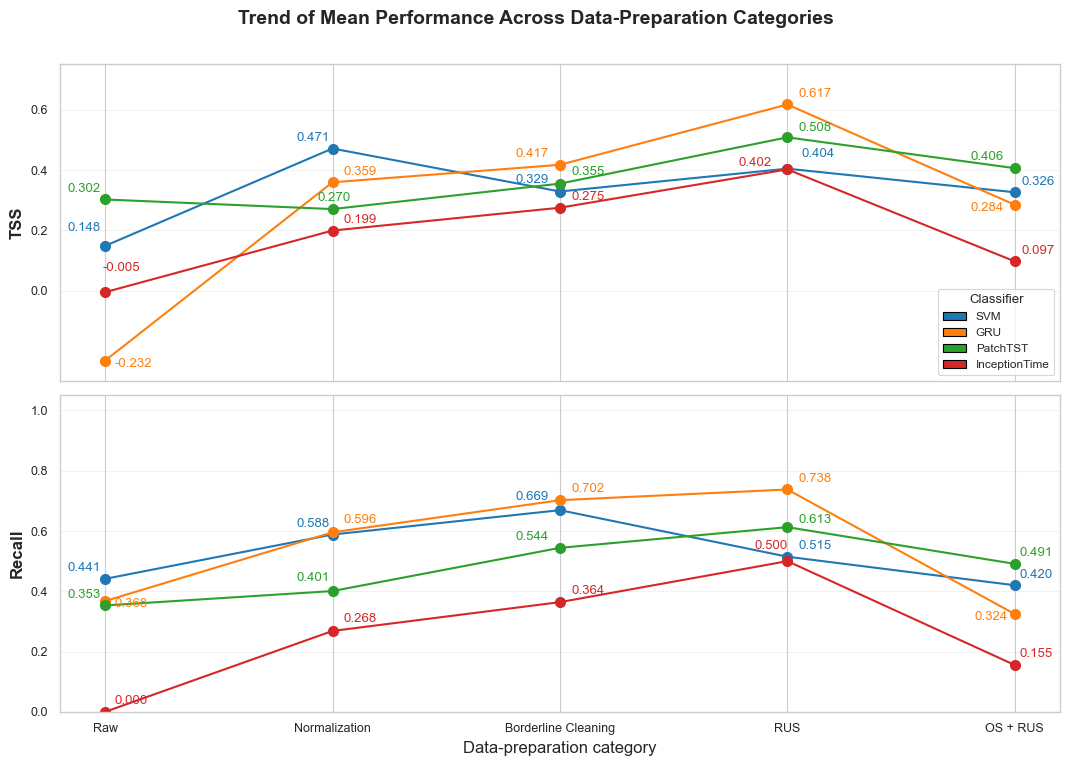

In [53]:
# ══════════════════════════════════════════════════════════════
# CATEGORY-LEVEL TREND OF TSS AND RECALL
# Uses existing plot_df only
# Categories included:
#   Raw
#   Normalization
#   Borderline Cleaning
#   Random Undersampling
#   Oversampling + Random Undersampling
# Aggregation:
#   Mean score per classifier per category.
# Layout:
#   Top panel    : Mean TSS
#   Bottom panel : Mean Recall
#   X-axis       : Data-preparation category
#   Lines        : classifiers
#   Text labels  : offset manually to reduce overlap
# Output:
#   PDF + PNG
# ══════════════════════════════════════════════════════════════

import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------
# Categories and classifiers
# ---------------------------------------------------------

category_name_map = {
    "1_normalization": "Normalization",
    "3_borderline_cleaning": "Borderline Cleaning",
    "4_random_undersampling": "RUS",
    "5_oversampling_and_rus": "OS + RUS"
}

category_order = [
    "1_normalization",
    "3_borderline_cleaning",
    "4_random_undersampling",
    "5_oversampling_and_rus"
]

category_label_order = [
    "Raw",
    "Normalization",
    "Borderline Cleaning",
    "RUS",
    "OS + RUS"
]

classifier_order = [
    "SVM",
    "GRU",
    "PatchTST",
    "InceptionTime"
]

figure_df = plot_df[
    plot_df["category_key"].isin(category_order)
].copy()

figure_df["category_label"] = figure_df["category_key"].map(category_name_map)

# ---------------------------------------------------------
# Put Raw as its own category at the start
# ---------------------------------------------------------

figure_df.loc[
    (figure_df["category_key"] == "1_normalization") &
    (figure_df["method"] == "Raw"),
    "category_label"
] = "Raw"

figure_df["category_label"] = pd.Categorical(
    figure_df["category_label"],
    categories=category_label_order,
    ordered=True
)

figure_df["classifier_label"] = pd.Categorical(
    figure_df["classifier_label"],
    categories=classifier_order,
    ordered=True
)

# ---------------------------------------------------------
# Compute mean score per classifier/category/metric
# ---------------------------------------------------------

mean_df = (
    figure_df
    .groupby(
        ["classifier_label", "category_label", "metric"],
        as_index=False,
        observed=False
    )["score"]
    .mean()
    .rename(columns={"score": "mean_score"})
)

mean_df = mean_df.dropna(subset=["mean_score"]).copy()

print("Category-level mean scores:")
print(mean_df.to_string(index=False))

palette = sns.color_palette("tab10", n_colors=len(classifier_order))
classifier_colors = {
    clf: palette[i]
    for i, clf in enumerate(classifier_order)
}

# ---------------------------------------------------------
# Manual label offsets to reduce overlap
# Format: (x_offset, y_offset, horizontal_alignment)
# ---------------------------------------------------------

label_offsets = {
    # Raw
    ("TSS", "SVM", "Raw"): (-0.02, 0.04, "right"),
    ("TSS", "GRU", "Raw"): (0.04, -0.03, "left"),
    ("TSS", "PatchTST", "Raw"): (-0.02, 0.016, "right"),
    ("TSS", "InceptionTime", "Raw"): (-0.01, 0.06, "left"),

    ("Recall", "SVM", "Raw"): (-0.02, 0.016, "right"),
    ("Recall", "GRU", "Raw"): (0.04, -0.03, "left"),
    ("Recall", "PatchTST", "Raw"): (-0.02, 0.016, "right"),
    ("Recall", "InceptionTime", "Raw"): (0.04, 0.016, "left"),

    # Existing categories
    ("TSS", "SVM", "Normalization"): (-0.01, 0.016, "right"),
    ("TSS", "SVM", "Borderline Cleaning"): (-0.05, 0.02, "right"),
    ("TSS", "SVM", "RUS"): (0.06, 0.028, "left"),
    ("TSS", "SVM", "OS + RUS"): (0.03, 0.016, "left"),

    ("TSS", "GRU", "Normalization"): (0.05, 0.016, "left"),
    ("TSS", "GRU", "Borderline Cleaning"): (-0.05, 0.016, "right"),
    ("TSS", "GRU", "RUS"): (0.05, 0.016, "left"),
    ("TSS", "GRU", "OS + RUS"): (-0.05, -0.03, "right"),

    ("TSS", "PatchTST", "Normalization"): (0.08, 0.016, "right"),
    ("TSS", "PatchTST", "Borderline Cleaning"): (0.05, 0.02, "left"),
    ("TSS", "PatchTST", "RUS"): (0.05, 0.01, "left"),
    ("TSS", "PatchTST", "OS + RUS"): (-0.05, 0.016, "right"),

    ("TSS", "InceptionTime", "Normalization"): (0.05, 0.016, "left"),
    ("TSS", "InceptionTime", "Borderline Cleaning"): (0.05, 0.016, "left"),
    ("TSS", "InceptionTime", "RUS"): (-0.07, -0.0, "right"),
    ("TSS", "InceptionTime", "OS + RUS"): (0.03, 0.016, "left"),

    ("Recall", "SVM", "Normalization"): (-0.01, 0.016, "right"),
    ("Recall", "SVM", "Borderline Cleaning"): (-0.05, 0.025, "right"),
    ("Recall", "SVM", "RUS"): (0.05, 0.016, "left"),
    ("Recall", "SVM", "OS + RUS"): (0.02, 0.016, "left"),

    ("Recall", "GRU", "Normalization"): (0.05, 0.02, "left"),
    ("Recall", "GRU", "Borderline Cleaning"): (0.05, 0.016, "left"),
    ("Recall", "GRU", "RUS"): (0.05, 0.016, "left"),
    ("Recall", "GRU", "OS + RUS"): (-0.03, -0.03, "right"),

    ("Recall", "PatchTST", "Normalization"): (-0.01, 0.025, "right"),
    ("Recall", "PatchTST", "Borderline Cleaning"): (-0.05, 0.016, "right"),
    ("Recall", "PatchTST", "RUS"): (0.05, 0.005, "left"),
    ("Recall", "PatchTST", "OS + RUS"): (0.02, 0.016, "left"),

    ("Recall", "InceptionTime", "Normalization"): (0.05, 0.02, "left"),
    ("Recall", "InceptionTime", "Borderline Cleaning"): (0.05, 0.019, "left"),
    ("Recall", "InceptionTime", "RUS"): (-0.0, 0.029, "right"),
    ("Recall", "InceptionTime", "OS + RUS"): (0.02, 0.016, "left"),
}

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10.8, 7.8),
    sharex=True
)

for ax, metric in zip(axes, ["TSS", "Recall"]):

    df_metric = mean_df[
        mean_df["metric"] == metric
    ].copy()

    for clf in classifier_order:

        df_clf = df_metric[
            df_metric["classifier_label"] == clf
        ].copy()

        df_clf = df_clf.sort_values("category_label")

        x_positions = [
            category_label_order.index(str(cat))
            for cat in df_clf["category_label"]
        ]

        ax.plot(
            x_positions,
            df_clf["mean_score"],
            marker="o",
            linewidth=1.5,
            markersize=7,
            color=classifier_colors[clf],
            label=clf
        )

        # -------------------------------------------------
        # Add value labels with manual offsets
        # -------------------------------------------------

        for _, row in df_clf.iterrows():

            category_label = str(row["category_label"])
            clf_name = str(row["classifier_label"])

            x_offset, y_offset, ha = label_offsets.get(
                (metric, clf_name, category_label),
                (0.04, 0.016, "left")
            )

            x_pos = category_label_order.index(category_label) + x_offset
            y_pos = row["mean_score"] + y_offset

            ax.text(
                x_pos,
                y_pos,
                f"{row['mean_score']:.3f}",
                ha=ha,
                va="bottom",
                fontsize=9.5,
                color=classifier_colors[clf]
            )

    ax.set_ylabel(metric, fontsize=12, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.25)

    if metric == "TSS":
        ax.set_ylim(-0.3, 0.75)
        ax.set_yticks([0.0, 0.2, 0.4, 0.6])
    else:
        ax.set_ylim(0.0, 1.05)
        ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

    ax.set_xticks(range(len(category_label_order)))
    ax.set_xticklabels(category_label_order)

    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

axes[-1].set_xlabel(
    "Data-preparation category",
    fontsize=12,
)

legend_handles = [
    Patch(
        facecolor=classifier_colors[clf],
        edgecolor="black",
        label=clf
    )
    for clf in classifier_order
]

axes[0].legend(
    handles=legend_handles,
    title="Classifier",
    loc="lower right",
    fontsize=8.5,
    title_fontsize=9.5,
    frameon=True
)

fig.suptitle(
    "Trend of Mean Performance Across Data-Preparation Categories",
    fontsize=14,
    fontweight="bold",
    y=0.975
)

plt.tight_layout(rect=[0, 0, 1, 0.965])

pdf_path = os.path.join(FIGURE_DIR, "mean_performance_trend_categories_sep_prediction.pdf")
png_path = os.path.join(FIGURE_DIR, "mean_performance_trend_categories_sep_prediction.png")

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")

plt.show()

Selected best variant per category based on mean TSS across all classifiers:
                category_key      category_label      method    method_clean  mean_tss
             1_normalization       Normalization      Hybrid     Hybrid Norm  0.479574
2_timespan_reduction_removed Borderline Cleaning ADASYN 1000    1000 Non-SEP       NaN
       3_borderline_cleaning Borderline Cleaning         ENN             ENN  0.524825
      4_random_undersampling                 RUS    RUS 8000       8000 NSEP  0.530594
      5_oversampling_and_rus            OS + RUS ADASYN 1000 ADASYN 1000 SEP  0.423075
Best variant figure rows: 64
Saved PDF: ./figures_final_pipeline/best_variant_per_category_sep_prediction.pdf
Saved PNG: ./figures_final_pipeline/best_variant_per_category_sep_prediction.png


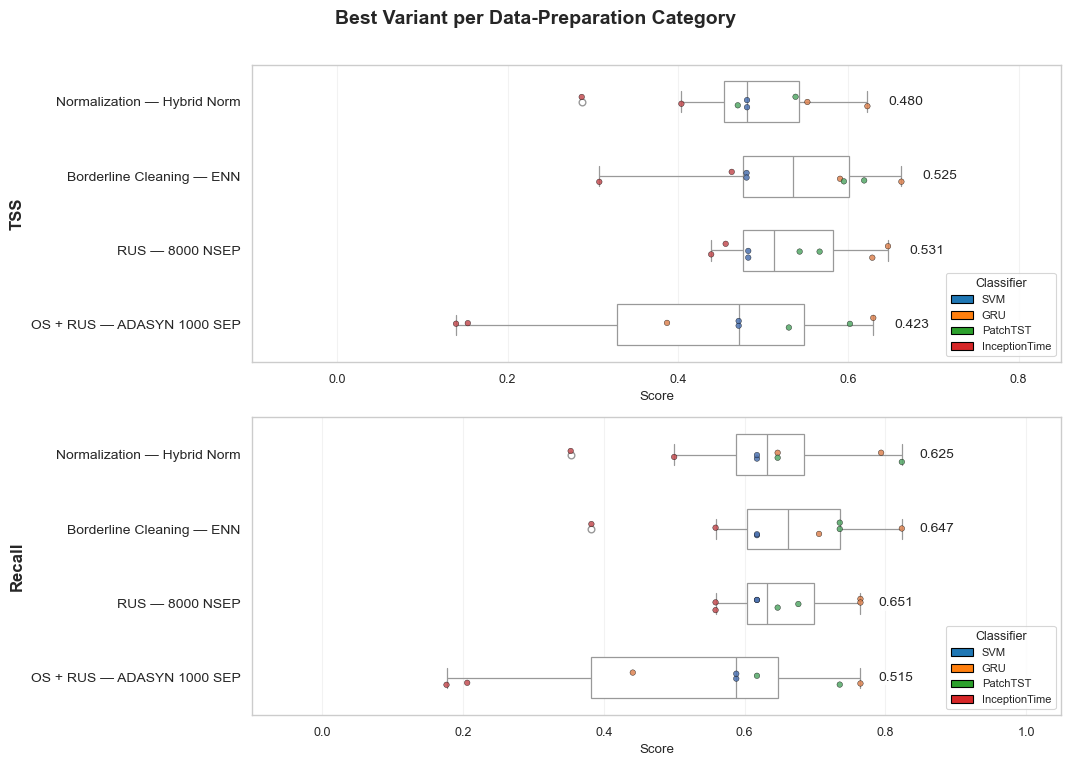

In [54]:
# ══════════════════════════════════════════════════════════════
# BEST VARIANT PER DATA-PREPARATION CATEGORY
# Uses existing plot_df only
# Categories included:
#   Normalization
#   Borderline Cleaning
#   Random Undersampling
#   Oversampling + Random Undersampling
# Selection:
#   For each category, average each variant across all 4 classifiers
#   and select the variant with the highest mean TSS.
# Layout:
#   Top panel    : TSS
#   Bottom panel : Recall
#   Left label   : TSS / Recall
#   Y-axis       : Category — best variant
#   Points       : individual classifier/run results
#   Colors       : classifiers
#   Text         : mean score shown after each box/whisker
# Output:
#   PDF + PNG
# ══════════════════════════════════════════════════════════════

import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------
# Categories included
# ---------------------------------------------------------

category_name_map = {
    "1_normalization": "Normalization",
    "3_borderline_cleaning": "Borderline Cleaning",
    "4_random_undersampling": "RUS",
    "5_oversampling_and_rus": "OS + RUS"
}

category_order = [
    "1_normalization",
    "3_borderline_cleaning",
    "4_random_undersampling",
    "5_oversampling_and_rus"
]

classifier_order = [
    "SVM",
    "GRU",
    "PatchTST",
    "InceptionTime"
]

figure_df = plot_df[
    plot_df["category_key"].isin(category_order)
].copy()

figure_df["category_label"] = figure_df["category_key"].map(category_name_map)

# ---------------------------------------------------------
# Clean method labels
# ---------------------------------------------------------

figure_df["method_clean"] = figure_df["method"].replace({
    # Normalization
    "Min-max": "Min-Max Norm",
    "Z-score": "Z-score Norm",
    "Log": "Log Norm",
    "Hybrid": "Hybrid Norm",

    # Borderline cleaning
    "Hybrid baseline": "No Cleaning",

    # Random undersampling
    "ENN baseline": "No RUS",
    "RUS 8000": "8000 NSEP",
    "RUS 4000": "4000 Non-SEP",
    "RUS 2000": "2000 Non-SEP",
    "RUS 1000": "1000 Non-SEP",
    "RUS 500": "500 Non-SEP",

    # SMOTE
    "SMOTE balanced": "SMOTE OS only",
    "SMOTE 8000": "SMOTE+RUS 8000",
    "SMOTE 4000": "SMOTE+RUS 4000",
    "SMOTE 2000": "SMOTE+RUS 2000",
    "SMOTE 1000": "SMOTE+RUS 1000",
    "SMOTE 500": "SMOTE+RUS 500",

    # ADASYN
    "ADASYN balanced": "ADASYN OS only",
    "ADASYN 8000": "ADASYN+RUS 8000",
    "ADASYN 4000": "ADASYN+RUS 4000",
    "ADASYN 2000": "ADASYN+RUS 2000",
    "ADASYN 1000": "ADASYN 1000 SEP",
    "ADASYN 500": "ADASYN+RUS 500",

    # TimeGAN
    "TimeGAN balanced": "TimeGAN OS only",
    "TimeGAN 8000": "TimeGAN+RUS 8000",
    "TimeGAN 4000": "TimeGAN+RUS 4000",
    "TimeGAN 2000": "TimeGAN+RUS 2000",
    "TimeGAN 1000": "TimeGAN+RUS 1000",
    "TimeGAN 500": "TimeGAN+RUS 500",
})

figure_df["classifier_label"] = pd.Categorical(
    figure_df["classifier_label"],
    categories=classifier_order,
    ordered=True
)

# ---------------------------------------------------------
# Select best variant per category using mean TSS
# averaged across all classifiers and runs
# ---------------------------------------------------------

tss_mean_df = (
    figure_df[figure_df["metric"] == "TSS"]
    .groupby(
        ["category_key", "category_label", "method", "method_clean"],
        as_index=False
    )["score"]
    .mean()
    .rename(columns={"score": "mean_tss"})
)

best_variants = (
    tss_mean_df
    .sort_values(
        by=["category_key", "mean_tss"],
        ascending=[True, False]
    )
    .groupby("category_key", as_index=False)
    .first()
)

print("Selected best variant per category based on mean TSS across all classifiers:")
print(best_variants.to_string(index=False))

# ---------------------------------------------------------
# Keep only selected best variants
# ---------------------------------------------------------

best_plot_df = figure_df.merge(
    best_variants[
        ["category_key", "method"]
    ],
    on=["category_key", "method"],
    how="inner"
)

best_plot_df["group_label"] = (
    best_plot_df["category_label"].astype(str)
    + " — "
    + best_plot_df["method_clean"].astype(str)
)

group_order = []

for category_key in category_order:
    selected = best_variants[
        best_variants["category_key"] == category_key
    ]

    if len(selected) > 0:
        category_label = selected["category_label"].iloc[0]
        method_label = selected["method_clean"].iloc[0]
        group_order.append(
            f"{category_label} — {method_label}"
        )

best_plot_df["group_label"] = pd.Categorical(
    best_plot_df["group_label"],
    categories=group_order,
    ordered=True
)

palette = sns.color_palette("tab10", n_colors=len(classifier_order))
classifier_colors = {
    clf: palette[i]
    for i, clf in enumerate(classifier_order)
}

print("Best variant figure rows:", len(best_plot_df))

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10.8, 7.8),
    sharex=False
)

for ax, metric in zip(axes, ["TSS", "Recall"]):

    df_metric = best_plot_df[
        best_plot_df["metric"] == metric
    ].copy()

    sns.boxplot(
        data=df_metric,
        y="group_label",
        x="score",
        order=group_order,
        orient="h",
        ax=ax,
        width=0.55,
        showfliers=True,
        linewidth=0.9,
        color="white"
    )

    sns.stripplot(
        data=df_metric,
        y="group_label",
        x="score",
        hue="classifier_label",
        order=group_order,
        hue_order=classifier_order,
        orient="h",
        ax=ax,
        dodge=False,
        size=4.0,
        alpha=0.85,
        linewidth=0.30,
        edgecolor="black",
        legend=False
    )

    # -----------------------------------------------------
    # Add mean value after each box/whisker
    # -----------------------------------------------------

    stats_values = (
        df_metric
        .groupby("group_label", observed=False)["score"]
        .agg(["mean", "max"])
        .reindex(group_order)
    )

    if metric == "TSS":
        ax.set_xlim(-0.1, 0.85)
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
        text_offset = 0.025
        max_text_x = 0.825
    else:
        ax.set_xlim(-0.1, 1.05)
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        text_offset = 0.025
        max_text_x = 1.025

    for y_pos, label in enumerate(group_order):
        mean_score = stats_values.loc[label, "mean"]
        max_score = stats_values.loc[label, "max"]

        if pd.notna(mean_score) and pd.notna(max_score):
            text_x = min(max_score + text_offset, max_text_x)

            ax.text(
                text_x,
                y_pos,
                f"{mean_score:.3f}",
                va="center",
                ha="left",
                fontsize=10,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.82,
                    pad=1.0
                )
            )

    ax.set_xlabel("Score")
    ax.set_ylabel(metric, fontsize=12, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.25)

    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=9)

    legend_handles = [
        Patch(
            facecolor=classifier_colors[clf],
            edgecolor="black",
            label=clf
        )
        for clf in classifier_order
    ]

    ax.legend(
        handles=legend_handles,
        title="Classifier",
        loc="lower right",
        fontsize=8,
        title_fontsize=9,
        frameon=True
    )

fig.suptitle(
    "Best Variant per Data-Preparation Category",
    fontsize=14,
    fontweight="bold",
    y=0.975
)

plt.tight_layout(rect=[0, 0, 1, 0.965])

pdf_path = os.path.join(FIGURE_DIR, "best_variant_per_category_sep_prediction.pdf")
png_path = os.path.join(FIGURE_DIR, "best_variant_per_category_sep_prediction.png")

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")

plt.show()